### 병해충 데이터 추출

In [ ]:
# -*- coding: utf-8 -*-
import os, re, glob
import pandas as pd

# ================== 설정 ==================
INPUT_DIR = "/Users/doyoung-gil/연구실/데이터/관찰데이터+지점ID+datetime"
OUT_DIR   = "/Users/doyoung-gil/연구실/데이터/사과"
os.makedirs(OUT_DIR, exist_ok=True)

# 기간
DATE_COL   = "조사일자(YYYYMMDD)"
DATE_START = pd.Timestamp("2013-01-01")
DATE_END   = pd.Timestamp("2024-12-31")

CORE = [
    "지점ID", "조사년도", "지역-시도", "지역-시군구", "지역-읍면동",
    "상세주소", "좌표-경도", "좌표-위도", "조사회차",
    DATE_COL,
    "작물명", "품종명"
]

# ▶ Extras 보존 여부/방식 
KEEP_EXTRAS   = False   # False면 extras 제거
PREFIX_EXTRAS = True    # True면 'CROP__컬럼명' 접두어

# 추출 대상
PEST_TARGETS = {
    "복숭아순나방": ["복숭아순나방"],
}

import re

def build_pattern(aliases):
    # '한글 글자'에 붙어있지 않을 때만 매치 (붙이 제외)
    parts = [fr"(?<![가-힣]){re.escape(a)}(?![가-힣])" for a in aliases]
    return re.compile("|".join(parts))

# 한번만 컴파일해서 재사용
PEST_PATTERNS = {name: build_pattern(aliases) for name, aliases in PEST_TARGETS.items()}

def pick_pest_cols(df: pd.DataFrame, pest_name: str) -> list:
    pat = PEST_PATTERNS[pest_name]
    return [c for c in df.columns if pat.search(str(c))]


# 탐색 방식
RECURSIVE = False  # 하위 폴더까지 포함하려면 True

# =============================================================
def detect_crop_from_name(fname: str) -> str:
    """파일명에서 작물명 추정"""
    m = re.search(r"RDA_OBSERVATION_([^_]+)_with_siteid_dt\.csv", fname)
    return m.group(1).upper() if m else "UNKNOWN"

def load_one(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, encoding="utf-8-sig")

    # 작물명 보정(없으면 파일명에서 추정)
    if "작물명" not in df.columns:
        df["작물명"] = detect_crop_from_name(os.path.basename(path))

    # 날짜 파싱 + 기간 필터
    if DATE_COL not in df.columns:
        print(f"[건너뜀] {os.path.basename(path)}: '{DATE_COL}' 컬럼 없음")
        return pd.DataFrame()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
    df = df[(df[DATE_COL] >= DATE_START) & (df[DATE_COL] <= DATE_END)]
    if df.empty:
        print(f"[건너뜀] {os.path.basename(path)}: 기간 내 데이터 없음")
        return pd.DataFrame()

    # 조사년도 생성/보정
    if "조사년도" not in df.columns:
        df["조사년도"] = df[DATE_COL].dt.year
    else:
        bad_mask = ~df["조사년도"].astype(str).str.fullmatch(r"\d{4}", na=False)
        df.loc[bad_mask, "조사년도"] = df.loc[bad_mask, DATE_COL].dt.year

    # 정렬
    sort_keys = [c for c in ["지점ID", DATE_COL] if c in df.columns]
    if sort_keys:
        df = df.sort_values(sort_keys)

    return df


# === 메인: 파일 수집 ===
if RECURSIVE:
    files = sorted(glob.glob(os.path.join(INPUT_DIR, "**", "RDA_OBSERVATION_*_with_siteid_dt.csv"), recursive=True))
else:
    files = sorted(glob.glob(os.path.join(INPUT_DIR, "RDA_OBSERVATION_*_with_siteid_dt.csv")))

if not files:
    raise SystemExit(f"대상 파일이 없습니다: {INPUT_DIR}")

# === 로드 & 병합 (병해충별) ===
from collections import defaultdict
pest_to_parts = defaultdict(list)

for fp in files:
    df_part = load_one(fp)
    if df_part.empty:
        continue

    core_present = [c for c in CORE if c in df_part.columns]  # 실제 존재하는 Core만

    for pest_name in PEST_TARGETS:
        pest_cols = pick_pest_cols(df_part, pest_name)
        if not pest_cols:
            continue

        out = df_part[core_present + pest_cols].copy()
        # 병해 관련 값이 전부 결측인 행 제거
        out = out.dropna(subset=pest_cols, how="all")
        if out.empty:
            continue

        if KEEP_EXTRAS:
            used = set(core_present + pest_cols)
            extras = [c for c in df_part.columns if c not in used]
            if extras:
                if PREFIX_EXTRAS:
                    crop = out["작물명"].iloc[0] if "작물명" in out.columns and not out.empty \
                           else detect_crop_from_name(os.path.basename(fp))
                    extra_ren = {c: f"{crop}__{c}" for c in extras}
                    out = pd.concat([out, df_part.loc[out.index, extras].rename(columns=extra_ren)], axis=1)
                else:
                    out = pd.concat([out, df_part.loc[out.index, extras]], axis=1)

        pest_to_parts[pest_name].append(out)

if not pest_to_parts:
    raise SystemExit("추출할 데이터가 없습니다. 경로/파일/키워드/기간을 확인하세요.")

# === 저장 (병해충별 → 작물별 파일) ===
for pest_name, parts in pest_to_parts.items():
    all_df = pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()
    if all_df.empty:
        print(f"[경고] '{pest_name}' 데이터 없음")
        continue

    # 최종 정렬
    sort_keys = [c for c in ["지점ID", DATE_COL] if c in all_df.columns]
    if sort_keys:
        all_df = all_df.sort_values(sort_keys)
    all_df = all_df.drop_duplicates()

    # 작물별로 저장 (원래 코드 스타일 유지)
    if "작물명" in all_df.columns:
        for crop, g in all_df.groupby("작물명", dropna=False):
            # 컬럼 재정렬: Core → pest 관련 → 나머지
            core_present = [c for c in CORE if c in g.columns]
            pat = PEST_PATTERNS[pest_name]
            pest_cols = [c for c in g.columns if c not in core_present and pat.search(str(c))]
            extras = [c for c in g.columns if c not in core_present + pest_cols]
            g = g[core_present + pest_cols + extras]


            save_path = os.path.join(OUT_DIR, f"{pest_name}_{crop}_2013_2024.csv")
            g.to_csv(save_path, index=False, encoding="utf-8-sig")
            print(f"[저장] {save_path} (rows={len(g):,}, cols={len(g.columns)})")
    else:
        # 작물명 컬럼이 없으면 병해충 단일 파일로 저장
        save_path = os.path.join(OUT_DIR, f"{pest_name}_2013_2024.csv")
        all_df.to_csv(save_path, index=False, encoding="utf-8-sig")
        print(f"[저장] {save_path} (rows={len(all_df):,}, cols={len(all_df.columns)})")


### 복숭아순나방 사이트로 지점마스터 파일 만들기

In [ ]:
# make_site_master_from_leafblast_fix.py
from pathlib import Path

OBS_DIR = Path("/Users/doyoung-gil/연구실/데이터/사과")
BASE    = OBS_DIR / "복숭아순나방_APPLE_2013_2024.csv"
OUT     = OBS_DIR / "site_master.csv"

def read_df(path: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "euc-kr", "cp949", "utf-8"):
        try:
            return pd.read_csv(path, encoding=enc, dtype=str, low_memory=False)
        except Exception:
            continue
    return pd.read_csv(path, dtype=str, low_memory=False)

df = read_df(BASE)

# 컬럼 이름 정리
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={c: c.replace(" ", "") for c in df.columns})

# 필요한 컬럼 찾기
id_col  = next((c for c in df.columns if c.lower() in ("지점id","siteid","site_id","지점")), None)
lat_col = next((c for c in df.columns if "위도" in c), None)
lon_col = next((c for c in df.columns if "경도" in c), None)
if not all([id_col, lat_col, lon_col]):
    raise SystemExit(f"필수 컬럼을 찾지 못했습니다: id={id_col}, lat={lat_col}, lon={lon_col}")

sub = df[[id_col, lat_col, lon_col]].copy()
sub.columns = ["지점ID", "좌표-위도", "좌표-경도"]

# 지점ID는 문자열 유지
sub["지점ID"] = sub["지점ID"].astype(str).str.strip()

# 좌표만 숫자화
sub["좌표-위도"] = pd.to_numeric(sub["좌표-위도"], errors="coerce")
sub["좌표-경도"] = pd.to_numeric(sub["좌표-경도"], errors="coerce")

# 유효값만
sub = sub[(sub["지점ID"] != "") & sub["좌표-위도"].notna() & sub["좌표-경도"].notna()]

# 지점별 대표 좌표(반올림 후 중앙값)
master = (sub.round({"좌표-위도": 6, "좌표-경도": 6})
            .groupby("지점ID", as_index=False)
            .agg({"좌표-위도": "median", "좌표-경도": "median"}))

master.to_csv(OUT, index=False, encoding="utf-8-sig", float_format="%.6f")
print(f"[저장] {OUT} (지점 수={len(master):,})")
print(master.head())


### 이웃 관측소 마스터 만들기

In [ ]:
# build_neighbors_master_csv.py
# -*- coding: utf-8 -*-
import numpy as np

# ===== 설정 =====
EARTH_R   = 6371000.0     # 지구 반경(m)
IDW_POWER = 1.5           # IDW 가중치 지수 (w = 1/d^p)
K_NEIGH   = 3             # 지점ID당 이웃 관측소 개수

WEATHER_DIR = Path("/Users/doyoung-gil/연구실/데이터/ASOS+AWS/GDD")
SITE_MASTER = Path("/Users/doyoung-gil/연구실/데이터/사과/site_master.csv")
OUT_CSV     = Path("/Users/doyoung-gil/연구실/데이터/사과/neighbors_master.csv")
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

DATE_COL   = "일시"
DATE_START = pd.Timestamp("2013-01-01")
DATE_END   = pd.Timestamp("2025-01-19")


# ===== 함수 =====
def hv(lat1, lon1, lat2, lon2):
    """벡터화 하버사인 거리(m)"""
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2 * EARTH_R * np.arcsin(np.sqrt(a))

def read_weather_stations() -> pd.DataFrame:
    """기상 파일들에서 관측소 좌표만 모아서 고유 목록 반환."""
    parts = []
    for y in range(DATE_START.year, DATE_END.year + 1):
        p = WEATHER_DIR / f"ASOS_AWS_{y}_with_GDD10.csv"
        if not p.exists():
            continue
        w = pd.read_csv(p, encoding="utf-8-sig", low_memory=False)
        # 기간 필터(있을 때만)
        if DATE_COL in w.columns:
            w[DATE_COL] = pd.to_datetime(w[DATE_COL], errors="coerce").dt.normalize()
            w = w[(w[DATE_COL] >= DATE_START) & (w[DATE_COL] <= DATE_END)]
        # 좌표/ID 숫자화
        for c in ["지점", "위도", "경도"]:
            if c in w.columns:
                w[c] = pd.to_numeric(w[c], errors="coerce")
        parts.append(w[["지점", "위도", "경도"]])
    if not parts:
        raise SystemExit("관측소 좌표를 읽을 수 있는 기상 파일이 없습니다.")
    stn = pd.concat(parts, ignore_index=True).dropna().drop_duplicates()
    if stn.empty:
        raise SystemExit("관측소 좌표가 비어 있습니다.")
    return stn

def main():
    # 지점 마스터 로드 (지점ID는 문자열 유지)
    site = pd.read_csv(SITE_MASTER, dtype={"지점ID": str})
    site = site.dropna(subset=["좌표-위도", "좌표-경도"]).copy()
    site["지점ID"] = site["지점ID"].astype(str).str.strip()
    site = site[site["지점ID"] != ""].drop_duplicates(subset=["지점ID"])

    # 관측소 목록 로드
    stn = read_weather_stations()
    stn_lat = stn["위도"].to_numpy()
    stn_lon = stn["경도"].to_numpy()
    stn_ids = stn["지점"].to_numpy()

    rows = []
    for sid, slat, slon in site[["지점ID", "좌표-위도", "좌표-경도"]].itertuples(index=False):
        d = hv(float(slat), float(slon), stn_lat, stn_lon)       # 거리(m)
        k = min(K_NEIGH, len(stn_ids))
        order = np.argsort(d)[:k]
        d_k, ids_k = d[order], stn_ids[order]
        # 가중치(0m 보호)
        if np.isclose(d_k[0], 0.0):
            w = np.zeros_like(d_k); w[0] = 1.0
        else:
            w = 1.0 / np.power(np.maximum(d_k, 1.0), IDW_POWER)
        for r, (stn_id, dist, w_raw) in enumerate(zip(ids_k, d_k, w), start=1):
            rows.append((sid, int(stn_id), r, float(dist), float(w_raw)))

    neigh = pd.DataFrame(rows, columns=["지점ID", "지점", "rank", "거리_m", "w_raw"])
    neigh = neigh.sort_values(["지점ID", "rank"]).drop_duplicates(["지점ID", "rank"])

    # CSV 저장
    neigh.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
    # 간단 요약
    cnt_by_site = neigh.groupby("지점ID")["rank"].max()
    print(f"[저장] {OUT_CSV}  rows={len(neigh):,},  지점수={cnt_by_site.size:,}")
    print("지점별 이웃개수 분포:")
    print(cnt_by_site.value_counts().sort_index())

if __name__ == "__main__":
    main()


### 기상데이터(GDD) + 병해충데이터 병합 -> 시계열테이블

In [ ]:
# join_with_neighbors_master.py
from scipy.sparse import csr_matrix

# ======================= 설정 =======================
CROP  = "APPLE"  
NAMES = ["복숭아순나방"]
# NAMES = ["잎집무늬마름병", "흰잎마름병", "깨씨무늬병", "이화명나방", "벼멸구", "흰등멸구"]

DATE_START = pd.Timestamp("2013-01-01")
DATE_END   = pd.Timestamp("2025-01-31")
SPAN_TAG   = "2013_2024"
DATE_COL   = "일시"

# 경로
WEATHER_DIR = "/Users/doyoung-gil/연구실/데이터/ASOS+AWS/GDD"             # ASOS_AWS_YYYY_with_GDD10.csv
OBS_DIR     = "/Users/doyoung-gil/연구실/데이터/사과"                        # {이름}_{CROP}_{SPAN}.csv
NEIGH_CSV   = "/Users/doyoung-gil/연구실/데이터/사과/neighbors_master.csv"
OUT_DIR     = "/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples"      # 결과 저장
os.makedirs(OUT_DIR, exist_ok=True)

# ===== 결측 보강 설정 =====
FILL_METHOD = "nearest"   # "nearest" or "idw"
IDW_POWER   = 1.5         # idw일 때만 사용

# 원본 기상 열 → 표준 이름 매핑
WX_NAME_MAP = {
    "일강수량": ["일강수량(mm)", "일강수량"],
    "최고기온": ["최고기온(°C)", "최고기온(℃)", "최고기온"],
    "최저기온": ["최저기온(°C)", "최저기온(℃)", "최저기온"],
    "평균기온": ["평균기온(°C)", "평균기온(℃)", "평균기온"],
    "최대 풍속": ["최대 풍속(m/s)", "최대풍속(m/s)", "최대 풍속", "최대풍속",
               "최대 순간 풍속(m/s)", "최대순간풍속(m/s)"],
    "평균 풍속": ["평균 풍속(m/s)", "평균풍속(m/s)", "평균 풍속", "평균풍속"],
}

# 병해/해충별 키워드(열 이름 매칭용)
NAME_KEYS = {
    "복숭아순나방": ["복숭아순나방"]
}

ALWAYS_KEEP = ["품종명"]

# === 관측값 우선 컬럼 매핑  ===
PREFERRED_OBS_COLS = {
    "복숭아순나방": ["(트랩)복숭아순나방-마리수"]
}

# ======================= 유틸 =======================
def load_weather_year(y: int) -> pd.DataFrame | None:
    p = os.path.join(WEATHER_DIR, f"ASOS_AWS_{y}_with_GDD10.csv")
    if not os.path.exists(p):
        return None
    w = pd.read_csv(p, encoding="utf-8-sig", low_memory=False)
    w[DATE_COL] = pd.to_datetime(w[DATE_COL], errors="coerce").dt.normalize()
    for c in ["지점","위도","경도"]:
        if c in w.columns: w[c] = pd.to_numeric(w[c], errors="coerce")
    if {"지점", DATE_COL}.issubset(w.columns):
        w = w.drop_duplicates(subset=["지점", DATE_COL]).sort_values(["지점", DATE_COL])
    return w

def load_weather_range(start_ts, end_ts) -> pd.DataFrame:
    parts = []
    for y in range(start_ts.year, end_ts.year + 1):
        df = load_weather_year(y)
        if df is not None and not df.empty:
            parts.append(df)
    if not parts:
        raise FileNotFoundError("기간 내 기상 파일을 찾지 못했습니다.")
    wx = pd.concat(parts, ignore_index=True)
    wx = wx[(wx[DATE_COL] >= start_ts) & (wx[DATE_COL] <= end_ts)]
    return wx

def pick_first(df: pd.DataFrame, candidates: list):
    for c in candidates:
        if c in df.columns: return c
    return None

def standardize_weather_cols(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for std, cands in WX_NAME_MAP.items():
        src = pick_first(out, cands)
        out[std] = pd.to_numeric(out[src], errors="coerce") if src else np.nan
    if "DD10" not in out.columns and "DD" in out.columns:
        out.rename(columns={"DD": "DD10"}, inplace=True)
    if "GDD10_cum" not in out.columns and "GDD" in out.columns:
        out.rename(columns={"GDD": "GDD10_cum"}, inplace=True)
    return out

def pest_related_cols(df: pd.DataFrame, name: str) -> list:
    keys = [k.casefold() for k in NAME_KEYS.get(name, [name])]
    cols = []
    for c in df.columns:
        cl = str(c).casefold()
        if any(k in cl for k in keys):
            cols.append(c)
    return cols

def pick_rate_col(df: pd.DataFrame, name: str) -> str | None:
    keys = [k.casefold() for k in NAME_KEYS.get(name, [name])]
    cols_lower = {c: str(c).casefold() for c in df.columns}
    cands = [c for c, cl in cols_lower.items() if ("발생면적률" in cl) and any(k in cl for k in keys)]
    if not cands:
        return None
    def score(col):
        cl = cols_lower[col]
        best = max((len(k) for k in keys if k in cl), default=0)
        return (-best, len(col))
    return sorted(cands, key=score)[0]

# === 관측값 컬럼 선택 함수  ===
def build_ko_word_pat(term: str):
    # '복숭아순나방붙이' 같은 붙어있는 단어는 제외
    return re.compile(fr"(?<![가-힣]){re.escape(term)}(?![가-힣])", flags=re.IGNORECASE)

def pick_obs_value_col(df: pd.DataFrame, name: str) -> str | None:
    """
    1순위: PREFERRED_OBS_COLS[name] 중 존재하는 첫 컬럼(정확 매치 → 경계기반 부분매치 순)
    2순위: 없으면 '발생면적률' 폴백
    """
    prefs = PREFERRED_OBS_COLS.get(name, [])
    for p in prefs:
        if p in df.columns:
            return p
        pat = build_ko_word_pat(p)
        hits = [c for c in df.columns if pat.search(str(c))]
        if hits:
            return sorted(hits, key=len)[0]
    return pick_rate_col(df, name)

def aggregate_weather_by_neighbors(wx_all: pd.DataFrame,
                                   neighbors: pd.DataFrame,
                                   date_col: str,
                                   agg_cols: list,
                                   method: str = "idw",
                                   idw_power: float = 1.5) -> pd.DataFrame:
    """
    neighbors: ['지점ID','지점','rank','거리_m','w_raw'] (지점ID는 문자열)
    반환: ['지점ID', date_col] + agg_cols  (전 기간 매일)
    """
    # 사이트/스테이션 인덱싱
    site_ids = neighbors['지점ID'].astype(str).drop_duplicates().to_list()
    stn_ids  = wx_all['지점'].drop_duplicates().to_list()
    site_idx = {sid: i for i, sid in enumerate(site_ids)}
    stn_idx  = {sid: j for j, sid in enumerate(stn_ids)}
    n_sites  = len(site_ids)
    dates    = pd.date_range(DATE_START, DATE_END, freq="D")
    n_days   = len(dates)

    # 희소 가중치
    r_idx = neighbors['지점ID'].map(site_idx).to_numpy()
    c_idx = neighbors['지점'].map(stn_idx).to_numpy()
    w_raw = neighbors['w_raw'].astype(float).to_numpy()
    W = csr_matrix((w_raw, (r_idx, c_idx)), shape=(n_sites, len(stn_ids)))

    out = pd.DataFrame({
        '지점ID': np.repeat(site_ids, n_days),
        date_col: np.tile(dates.values, n_sites)
    })

    for col in agg_cols:
        mat = (wx_all.pivot(index=date_col, columns='지점', values=col)
                        .reindex(index=dates, columns=stn_ids))
        X = mat.to_numpy(dtype=float)          # (days x stations)
        valid = np.isfinite(X).astype(float)
        X_filled = np.nan_to_num(X, nan=0.0)

        if method == "idw":
            N = W.dot(X_filled.T).astype(float)    # (sites x days)
            D = W.dot(valid.T).astype(float)
            R = np.divide(N, D, out=np.full_like(N, np.nan), where=(D > 0))
            out[col] = R.reshape(n_sites * n_days, order='C')

        elif method == "nearest":
            # rank별 스테이션 인덱스 테이블 (sites x K)
            piv = (neighbors.sort_values(['지점ID', 'rank'])
                             .drop_duplicates(['지점ID','rank'])
                             .pivot(index='지점ID', columns='rank', values='지점')
                             .reindex(index=site_ids))
            idx_by_rank = piv.applymap(stn_idx.get).to_numpy(dtype=float)  # NaN 가능
            K = idx_by_rank.shape[1]
            R = np.full((n_days, n_sites), np.nan, dtype=float)
            for r in range(K):
                idx_r = idx_by_rank[:, r]
                mask_valid = np.isfinite(idx_r)
                if not mask_valid.any(): continue
                cols_r = idx_r.copy(); cols_r[~mask_valid] = 0
                vals_r = X[:, cols_r.astype(int)]
                vals_r[:, ~mask_valid] = np.nan
                fill_mask = np.isnan(R) & np.isfinite(vals_r)
                R[fill_mask] = vals_r[fill_mask]
            out[col] = R.T.reshape(n_sites * n_days, order='C')
        else:
            raise ValueError("method must be 'idw' or 'nearest'")
    return out

# ======================= 메인 =======================
def main():
    # 1) 기상 로드 & 표준화
    wx_all = load_weather_range(DATE_START, DATE_END)
    wx_all = standardize_weather_cols(wx_all)
    stn = wx_all[["지점", "위도", "경도"]].dropna().drop_duplicates()
    if stn.empty:
        raise SystemExit("기상 관측소 좌표가 없습니다.")

    # 2) 이웃 마스터 로드 (CSV)
    neighbors_master = pd.read_csv(NEIGH_CSV, dtype={"지점ID": str})
    neighbors_master = (neighbors_master.sort_values(['지점ID','rank'])
                                         .drop_duplicates(['지점ID','rank']))

    # 3) 병해/해충별 처리
    for name in NAMES:
        fp = os.path.join(OBS_DIR, f"{name}_{CROP}_{SPAN_TAG}.csv")
        if not os.path.exists(fp):
            print(f"[스킵] 관찰 파일 없음: {fp}")
            continue

        obs = pd.read_csv(fp, encoding="utf-8-sig", low_memory=False)
        # 날짜 보정
        if DATE_COL not in obs.columns and "조사일자(YYYYMMDD)" in obs.columns:
            obs[DATE_COL] = pd.to_datetime(obs["조사일자(YYYYMMDD)"], errors="coerce").dt.normalize()
        else:
            obs[DATE_COL] = pd.to_datetime(obs.get(DATE_COL), errors="coerce").dt.normalize()
        obs = obs[(obs[DATE_COL] >= DATE_START) & (obs[DATE_COL] <= DATE_END)].copy()
        if obs.empty:
            print(f"[스킵] '{name}': 기간 내 관찰 없음")
            continue

        # 이번 병해충에 등장하는 지점ID만 슬라이스
        site_ids = pd.Series(obs["지점ID"].astype(str).dropna().unique())
        neighbors = neighbors_master[neighbors_master["지점ID"].isin(site_ids)]
        if neighbors.empty:
            print(f"[스킵] '{name}': neighbors가 비어 있음(지점ID 매칭 실패)")
            continue

        # 전 기간 base (모든 지점ID × 날짜)
        days = pd.date_range(DATE_START, DATE_END, freq="D")
        base = (pd.DataFrame({"지점ID": site_ids})
                  .assign(key=1)
                  .merge(pd.DataFrame({DATE_COL: days, "key":1}), on="key")
                  .drop(columns="key"))

        agg_cols = ["일강수량", "최고기온", "최대 풍속", "최저기온", "평균 풍속", "평균기온", "DD10", "GDD10_cum"]
        wx_use = wx_all[["지점", DATE_COL] + agg_cols].copy()

        # 결측 보강 기상 계산
        wx_filled = aggregate_weather_by_neighbors(wx_use, neighbors, DATE_COL, agg_cols,
                                                   method=FILL_METHOD, idw_power=IDW_POWER)
        out = base.merge(wx_filled, on=["지점ID", DATE_COL], how="left")

        # 관찰 조인
        pest_cols = pest_related_cols(obs, name)
        keep_extra = [c for c in ALWAYS_KEEP if c in obs.columns]
        obs_keep_cols = ["지점ID", DATE_COL] + pest_cols + keep_extra

        # 품종명은 여러 값이 있어도 first로(필요 시 결합함수로 교체 가능)
        def join_unique_in_order(series, sep="|"):
            vals = pd.unique(series.dropna().astype(str))
            return sep.join(vals)

        agg = {}
        if "품종명" in obs_keep_cols:
            # 여러 품종 그대로 결합하고 싶으면 아래 줄로 바꿔도 됨:
            # agg["품종명"] = join_unique_in_order
            agg["품종명"] = "first"
        for c in pest_cols:
            if c not in agg: agg[c] = "first"

        obs_daily = (obs[obs_keep_cols]
                     .groupby(["지점ID", DATE_COL], as_index=False)
                     .agg(agg) if agg else obs[obs_keep_cols])

        out = out.merge(obs_daily, on=["지점ID", DATE_COL], how="left")

        # === 관측값/발생여부: 우선 (트랩)복숭아순나방-마리수 사용 ===
        val_col = pick_obs_value_col(out, name)
        if val_col:
            out["관측값"] = pd.to_numeric(out[val_col], errors="coerce")
            out["발생여부"] = (out["관측값"].fillna(0) > 0).astype(int)
        else:
            out["관측값"] = np.nan
            out["발생여부"] = np.nan
            print(f"[알림] '{name}': 관측값으로 사용할 컬럼을 찾지 못함 → 관측값/발생여부 NaN")

        # 단위 포함 컬럼 복제
        out["일강수량(mm)"]   = out["일강수량"]
        out["최고기온(°C)"]   = out["최고기온"]
        out["최대 풍속(m/s)"] = out["최대 풍속"]
        out["최저기온(°C)"]   = out["최저기온"]
        out["평균 풍속(m/s)"] = out["평균 풍속"]
        out["평균기온(°C)"]   = out["평균기온"]

        # 컬럼 순서
        front = ["지점ID", DATE_COL, "품종명",
                 "일강수량(mm)", "최고기온(°C)", "최대 풍속(m/s)",
                 "최저기온(°C)", "평균 풍속(m/s)", "평균기온(°C)"]
        pest_cols = [c for c in pest_cols if c not in set(front + ALWAYS_KEEP)]
        tail  = ["DD10", "GDD10_cum", "관측값", "발생여부"]
        cols  = front + pest_cols + tail
        for c in cols:
            if c not in out.columns: out[c] = np.nan

        out = (out.loc[:, cols]
                 .drop_duplicates(subset=["지점ID", DATE_COL])
                 .sort_values(["지점ID", DATE_COL])
                 .reset_index(drop=True))

        save_path = os.path.join(OUT_DIR, f"joined_SAMPLE_GDD_{SPAN_TAG}_{CROP}_{name}.csv")
        out.to_csv(save_path, index=False, encoding="utf-8-sig", float_format="%.1f")
        print(f"[저장] {save_path}  rows={len(out):,}, cols={len(out.columns)}")

if __name__ == "__main__":
    main()

### site별 쪼개기

In [ ]:
# split_timeseries_by_site_simple.py

IN_DIR   = "/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples"
OUT_ROOT = "/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples"
FILE_GLOB = "joined_SAMPLE_GDD_2013_2024_APPLE_복숭아순나방.csv"  

SITE_COL = "지점ID" 

def sanitize_for_filename(s) -> str:
    """파일명에 쓸 수 있게 간단 정제(공백/특수문자 -> _)"""
    import re
    s = "NA" if pd.isna(s) else str(s).strip()
    return re.sub(r'[^0-9A-Za-z가-힣_.-]+', "_", s)

def parse_crop_name(fname: str):
    """
    파일명: joined_SAMPLE_GDD_{SPAN}_{CROP}_{NAME}.csv
    예시 : joined_SAMPLE_GDD_20221101_20241119_RICE_흰등멸구.csv
    """
    base = os.path.basename(fname)
    m = re.match(r"joined_SAMPLE_GDD_.+?_([A-Za-z]+)_(.+)\.csv$", base)
    if not m:
        return None, None
    crop = m.group(1).upper()
    name = m.group(2)
    return crop, name

def main():
    files = sorted(glob.glob(os.path.join(IN_DIR, FILE_GLOB)))
    if not files:
        raise SystemExit(f"[종료] 입력 없음: {os.path.join(IN_DIR, FILE_GLOB)}")

    for fp in files:
        crop, name = parse_crop_name(fp)
        if crop is None:
            print(f"[스킵] 파일명 패턴 불일치: {fp}")
            continue

        out_dir = os.path.join(OUT_ROOT, f"{name}_by_site")
        os.makedirs(out_dir, exist_ok=True)

        df = pd.read_csv(fp, encoding="utf-8-sig")

        if SITE_COL not in df.columns:
            print(f"[스킵] '{SITE_COL}' 컬럼 없음: {fp}")
            continue

        for site, g in df.groupby(SITE_COL, dropna=False):
            if pd.isna(site):
                continue
            site_str = sanitize_for_filename(site)
            out_path = os.path.join(out_dir, f"{crop}_{name}_site-{site_str}.csv")
            g.to_csv(out_path, index=False, encoding="utf-8-sig")
        print(f"[저장 완료] {name} → {out_dir}")

if __name__ == "__main__":
    main()

### WeatherMovingAverage 구하기

In [ ]:
# make_moving_windows_for_fuzzy.py

from pathlib import Path
import pandas as pd
import numpy as np
import re, os

# ===== 경로/설정 =====
IN_DIR  = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/복숭아순나방_by_site")
OUT_DIR = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage2")   # R 스크립트와 동일 폴더명
OUT_DIR.mkdir(parents=True, exist_ok=True)

YEAR_START = 2013
YEAR_END   = 2024
YEARS = list(range(YEAR_START, YEAR_END + 1))
OFFS = list(range(0, 30))     # 오프셋(일) OFFS  = [0, 5, 10, 15, 20, 25]
WIN   = 30                          # 창 길이(일)
STEP  = 30                          # 창 간격(일) = 30일씩 
DAYS_CONST = 30

# 원본 열 이름 매핑
COL_DATE  = "일시"
COL_TMAX  = "최고기온(°C)"
COL_TMIN  = "최저기온(°C)"
COL_TAVG  = "평균기온(°C)"
COL_WMEAN = "평균 풍속(m/s)"
COL_WGUST = "최대 풍속(m/s)"
COL_PRCP  = "일강수량(mm)"
COL_DD10  = "DD10"          # 없거나 전부 NaN이면 tavg 기반으로 계산: max(tavg-10, 0)

def parse_site_id(fname: str) -> str:
    base = os.path.basename(fname)
    m = re.search(r"site-([^./]+)", base)  # 파일명 'site-xxxx'
    return m.group(1) if m else os.path.splitext(base)[0]

def to_num(s): 
    return pd.to_numeric(s, errors="coerce")

def window_stats(d: pd.DataFrame):
    """30일 창 집계: 평균/최댓값/합계. 보간 없음, NaN은 제외하고 계산."""
    out = {}
    # 평균기온 결측 보정: (tmax+tmin)/2 (둘 다 있을 때만)
    tmax = to_num(d.get(COL_TMAX))
    tmin = to_num(d.get(COL_TMIN))
    tavg = to_num(d.get(COL_TAVG))
    if tavg is None:
        tavg = pd.Series(index=d.index, dtype="float64")
    tavg = tavg.copy()
    fill_mask = (tmax.notna() & tmin.notna() & tavg.isna())
    tavg[fill_mask] = (tmax[fill_mask] + tmin[fill_mask]) / 2.0

    out["tavg_mean_30d"] = float(tavg.mean(skipna=True))
    out["tmin_mean_30d"] = float(tmin.mean(skipna=True))
    out["tmax_mean_30d"] = float(tmax.mean(skipna=True))

    wmean = to_num(d.get(COL_WMEAN))
    wgust = to_num(d.get(COL_WGUST))
    prcp  = to_num(d.get(COL_PRCP))

    out["wind_mean_30d"]     = float(wmean.mean(skipna=True))
    out["wind_gust_max_30d"] = float(wgust.max(skipna=True))
    out["precip_sum_30d"]    = float(prcp.sum(skipna=True))

    dd10 = to_num(d.get(COL_DD10))
    if (dd10 is None) or (isinstance(dd10, pd.Series) and dd10.notna().sum() == 0):
        # DD10 열이 없거나 전부 결측이면 tavg로 대체 계산
        dd10 = np.maximum(tavg - 10.0, 0.0)
    out["gdd10_sum_30d"] = float(pd.Series(dd10).sum(skipna=True))
    return out

def gen_windows_for_year(year: int, offset_days: int):
    """
    해당 연도: 1월 1일 + offset에서 시작해 30일 창을 30일 간격으로 '딱 12개' 생성.
    (마지막 창은 다음 해로 넘어갈 수도 있음: 요구사항대로 그대로 둠)
    """
    base = pd.Timestamp(f"{year}-01-01")
    wins = []
    for i in range(12):
        start = base + pd.Timedelta(days=offset_days + i*STEP)
        end   = start + pd.Timedelta(days=WIN-1)  # 포함 끝
        wins.append((i+1, start, end))
    return wins

def process_one(fp: Path):
    df = pd.read_csv(fp, dtype={"지점ID":"string"}, low_memory=False)
    if COL_DATE not in df.columns:
        print(f"[스킵] 날짜 컬럼 없음: {fp.name}"); 
        return
    df[COL_DATE] = pd.to_datetime(df[COL_DATE], errors="coerce").dt.normalize()
    df = df.sort_values(COL_DATE)

    site_id = parse_site_id(fp.name)
    rows = []

    for yr in YEARS:
        for o in OFFS:
            for idx, start, end in gen_windows_for_year(yr, o):
                win = df[(df[COL_DATE] >= start) & (df[COL_DATE] <= end)]
                stats = (window_stats(win) if not win.empty else
                        {k: np.nan for k in [
                            "tavg_mean_30d","tmin_mean_30d","tmax_mean_30d",
                            "wind_mean_30d","wind_gust_max_30d","precip_sum_30d","gdd10_sum_30d"
                        ]})
                rows.append({
                    "site_id": site_id,
                    "year": yr,
                    "offset_days": o,
                    "window_idx": idx,
                    "start_date": start.date(),
                    "end_date": end.date(),
                    "days": DAYS_CONST,
                    **stats
                })

    out = pd.DataFrame(rows)

    # 최종 컬럼 순서 고정
    COL_ORDER = [
        "site_id","year","offset_days","window_idx",
        "start_date","end_date","days",
        "tavg_mean_30d","tmin_mean_30d","tmax_mean_30d",
        "wind_mean_30d","wind_gust_max_30d","precip_sum_30d","gdd10_sum_30d"
    ]
    site_id = parse_site_id(fp.name)
    out = out[COL_ORDER]

    out_fname = f"site-{site_id}_WeatherMovingAverage.csv" 
    out_path  = OUT_DIR / out_fname

    out.to_csv(out_path, index=False, encoding="utf-8-sig", float_format="%.3f")
    print(f"[저장] {out_path} rows={len(out):,}")

def main():
    files = sorted(IN_DIR.glob("*site-*.csv"))  
    if not files:
        print(f"[종료] 입력 없음: {IN_DIR}")
        return
    for fp in files:
        process_one(fp)

if __name__ == "__main__":
    main()

[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30523_63004_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30551_62994_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30636_62943_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30644_62932_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30670_56490_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30672_56490_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30676_56412_WeatherMovingAverage.csv rows=4,320
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/WeatherMovingAverage3/site-30697_56554_WeatherMovin

### site-관측소 매핑

In [ ]:
# build_neighbors_view_tight.py

from pathlib import Path
import numpy as np
import pandas as pd

# ===== 설정 =====
K_NEIGH        = 3                         # site당 이웃 관측소 수
MAX_RADIUS_KM  = None                      # 반경 제한 없으면 None
WEATHER_DIR    = Path("/Users/doyoung-gil/연구실/데이터/ASOS+AWS/GDD")
SITE_MASTER    = Path("/Users/doyoung-gil/연구실/데이터/사과/site_master.csv")
OUT_CSV        = Path("/Users/doyoung-gil/연구실/데이터/사과/neighbors_view.csv")
DATE_COL       = "일시"
DATE_START     = pd.Timestamp("2013-01-01")
DATE_END       = pd.Timestamp("2025-01-19")

EARTH_R = 6371000.0  # m

def hv(lat1, lon1, lat2, lon2):
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    return 2 * EARTH_R * np.arcsin(np.sqrt(a))  # meters

def read_stations_tight() -> pd.DataFrame:
    # 필요한 컬럼만 로드
    parts = []
    for y in range(DATE_START.year, DATE_END.year + 1):
        p = WEATHER_DIR / f"ASOS_AWS_{y}_with_GDD10.csv"
        if not p.exists():
            continue
        w = pd.read_csv(p, usecols=["지점","지점명","위도","경도", DATE_COL],
                        encoding="utf-8-sig", low_memory=False)
        w[DATE_COL] = pd.to_datetime(w[DATE_COL], errors="coerce").dt.normalize()
        w = w[(w[DATE_COL] >= DATE_START) & (w[DATE_COL] <= DATE_END)]
        w[["지점","위도","경도"]] = w[["지점","위도","경도"]].apply(
            pd.to_numeric, errors="coerce"
        )
        parts.append(w)
    if not parts:
        raise SystemExit("ASOS_AWS 원천에서 스테이션을 찾을 수 없습니다.")
    stn = (pd.concat(parts, ignore_index=True)
            .dropna(subset=["지점","위도","경도"])
            .drop_duplicates(subset=["지점"])  # 지점 ID 기준 고유화
            .sort_values("지점"))
    # 컬럼 통일
    stn = stn.rename(columns={"지점명":"관측소 지점명", "위도":"관측소 위도", "경도":"관측소 경도"})
    return stn[["지점","관측소 지점명","관측소 위도","관측소 경도"]].reset_index(drop=True)

def main():
    # 1) site master
    site = pd.read_csv(SITE_MASTER, dtype={"지점ID": str})
    site = (site.rename(columns={"지점ID":"site_id","좌표-위도":"site 위도","좌표-경도":"site 경도"})
                .dropna(subset=["site_id","site 위도","site 경도"]))
    site["site_id"] = site["site_id"].astype(str).str.strip()
    site = site[site["site_id"] != ""].drop_duplicates(subset=["site_id"])

    # 2) stations (tight)
    stn = read_stations_tight()
    stn_lat = stn["관측소 위도"].to_numpy()
    stn_lon = stn["관측소 경도"].to_numpy()

    rows = []
    for sid, slat, slon in site[["site_id","site 위도","site 경도"]].itertuples(index=False):
        d = hv(float(slat), float(slon), stn_lat, stn_lon)  # meters
        if MAX_RADIUS_KM is not None:
            mask = d <= (MAX_RADIUS_KM * 1000.0)
            if not mask.any():   # 반경 내 없으면 전체에서 k-NN
                order = np.argsort(d)[:K_NEIGH]
            else:
                order = np.argsort(d[mask])[:K_NEIGH]
                # mask 인덱스를 원래 인덱스로 복원
                order = np.where(mask)[0][order]
        else:
            order = np.argsort(d)[:K_NEIGH]

        for r, idx in enumerate(order, start=1):
            rows.append({
                "site_id": sid,
                "site 위도": float(slat),
                "site 경도": float(slon),
                "rank" : r,
                "관측소 지점명": stn.at[idx, "관측소 지점명"] if pd.notna(stn.at[idx, "관측소 지점명"]) else "",
                "관측소 위도": float(stn_lat[idx]),
                "관측소 경도": float(stn_lon[idx]),
                "site-관측소 거리": float(d[idx])  # meters
            })

    out = (pd.DataFrame(rows)
            .sort_values(["site_id","rank"])
            .drop_duplicates())  # 동일 거리/중복 방지

    out = out[[
    "site_id", "site 위도", "site 경도",
    "rank",
    "관측소 지점명", "관측소 위도", "관측소 경도",
    "site-관측소 거리"
    ]]
    
    OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(OUT_CSV, index=False, encoding="utf-8-sig", float_format="%.6f")
    print(f"[저장] {OUT_CSV}  rows={len(out):,}")

if __name__ == "__main__":
    main()

### (R로 fuzzy 돌린 이후) best + 위경도 매핑

In [9]:
# add_and_reorder_coords.py
from pathlib import Path
import pandas as pd

# --- 경로 설정 ---
COORD_CSV = Path("/Users/doyoung-gil/연구실/데이터/관찰데이터+지점ID+datetime/RDA_OBSERVATION_APPLE_with_siteid_dt.csv")
BEST_ROOT  = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy_Double/best")

# --- 좌표 마스터: '지점ID'를 'site_id'로 통일 후 매핑 ---
coord = (pd.read_csv(COORD_CSV, encoding="utf-8-sig")
           .rename(columns={"지점ID":"site_id", "좌표-위도":"lat", "좌표-경도":"lon"})
           [["site_id","lat","lon"]]
           .drop_duplicates("site_id")
           .set_index("site_id"))

files = sorted(set(BEST_ROOT.rglob("best_all_sites_DOY_newDormancyFullbloom.csv")) | set(BEST_ROOT.rglob("BEST_*.csv")))
print(f"[발견] {len(files)}개")

for f in files:
    df = pd.read_csv(f, encoding="utf-8-sig")

    # 좌표 붙이기
    m = df.merge(coord, on="site_id", how="left", copy=False)
    m["좌표-위도"] = m["lat"]
    m["좌표-경도"] = m["lon"]
    m.drop(columns=["lat","lon"], inplace=True)

    # site_id 바로 뒤로 재배치 (값/열 삭제 없음)
    cols = list(m.columns)
    cols.remove("좌표-위도")
    cols.remove("좌표-경도")
    pos = cols.index("site_id") + 1
    new_cols = cols[:pos] + ["좌표-위도","좌표-경도"] + cols[pos:]

    m[new_cols].to_csv(f, index=False, encoding="utf-8-sig")
    print(f"[저장] {f} rows={len(m)}")

print("[완료]")


[발견] 1개
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy_Double/best/best_all_sites_DOY_newDormancyFullbloom.csv rows=4548
[완료]


### 모든 지점별 best파일 합치기 + DOY 변환

In [8]:
# merge_best_and_dates_to_doy.py
from pathlib import Path
import pandas as pd

BEST_ROOT = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy_Double/best")
OUT_CSV   = BEST_ROOT / "best_all_sites_DOY.csv"

DATE_COLS = [
    "dormancy_start_date",
    "dormancy_end_date",
    "growing_start_date",
    "growing_end_date",
    "flowering_date",
    "fullbloom_date"
]

def to_doy(series: pd.Series) -> pd.Series:
    dt = pd.to_datetime(series, errors="coerce", format="%Y-%m-%d")
    return dt.dt.dayofyear.astype("Int64")

# === 파일 수집: 지점별 best_*.csv만, 통합본(best_all_sites*)은 제외 ===
files = sorted(set(BEST_ROOT.glob("best_*.csv")) | set(BEST_ROOT.glob("BEST_*.csv")))
files = [f for f in files if not f.name.startswith("best_all_sites")]
files = [f for f in files if f.resolve() != OUT_CSV.resolve()]

print(f"[발견] 대상 파일: {len(files)}개")
if not files:
    raise SystemExit("[중단] 병합할 파일이 없습니다. (best_<site>.csv가 있는지 확인)")

dfs = []
for f in files:
    try:
        df = pd.read_csv(f, encoding="utf-8-sig")
    except UnicodeDecodeError:
        df = pd.read_csv(f, encoding="utf-8")

    for col in DATE_COLS:
        if col in df.columns:
            df[col] = to_doy(df[col])

    # 좌표 컬럼 순서 정리(있으면 site_id 뒤로)
    need = ["site_id", "좌표-위도", "좌표-경도"]
    if all(c in df.columns for c in need):
        cols = list(df.columns)
        cols.remove("좌표-위도"); cols.remove("좌표-경도")
        pos = cols.index("site_id") + 1
        cols = cols[:pos] + ["좌표-위도", "좌표-경도"] + cols[pos:]
        df = df[cols]

    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)

# (선택) 혹시 모를 중복 키 제거: site_id+year 기준 1행만
if "site_id" in merged.columns and "year" in merged.columns:
    before = len(merged)
    merged = merged.sort_values(["site_id", "year"]).drop_duplicates(["site_id", "year"], keep="first")
    print(f"[중복제거] {before} -> {len(merged)} (site_id,year)")

merged.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")
print(f"[저장] {OUT_CSV}  rows={len(merged)}  cols={len(merged.columns)}")
print("[완료] 모든 날짜 컬럼을 DOY로 변환하여 합본 저장.")


[발견] 대상 파일: 379개
[중복제거] 4548 -> 4548 (site_id,year)
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy_Double/best/best_all_sites_DOY.csv  rows=4548  cols=15
[완료] 모든 날짜 컬럼을 DOY로 변환하여 합본 저장.


In [34]:
from pathlib import Path
import pandas as pd

# ===== 경로 설정 =====
BEST_ALL = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy3/best_all_sites_DOY2.csv")
RDA      = Path("/Users/doyoung-gil/연구실/AIM_PEX_DT03_샘플데이터/RDA_GROWTH_APPLE.csv")
OUT      = Path("/Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv")

# 좌표 컬럼 이름 (둘 파일 모두에 존재해야 함)
LAT_COL = "좌표-위도"
LON_COL = "좌표-경도"

# 좌표 반올림 정밀도(소수 N자리). 5 ≈ ~1.1m, 4 ≈ ~11m
PREC = 5

def read_csv_any(p: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "cp949", "euc-kr"):
        try:
            return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(p, low_memory=False)

# 1) 파일 읽기
best = read_csv_any(BEST_ALL)
rda  = read_csv_any(RDA)

# 2) 좌표 존재 확인
for df, name in [(best,"best_all_sites_DOY2"), (rda,"RDA_GROWTH_APPLE")]:
    missing = [c for c in (LAT_COL, LON_COL) if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] 필요한 컬럼 없음: {missing}. 실제 컬럼: {list(df.columns)[:10]} ...")

# 3) 반올림 기반 키 생성(부동소수 오차 방지)
best = best.copy()
rda  = rda.copy()
best["_lat_key"] = pd.to_numeric(best[LAT_COL], errors="coerce").round(PREC)
best["_lon_key"] = pd.to_numeric(best[LON_COL], errors="coerce").round(PREC)
rda["_lat_key"]  = pd.to_numeric(rda[LAT_COL], errors="coerce").round(PREC)
rda["_lon_key"]  = pd.to_numeric(rda[LON_COL], errors="coerce").round(PREC)

# 4) inner join으로 best 좌표에 해당하는 RDA 행만 선별
subset = rda.merge(
    best[["_lat_key","_lon_key"]].drop_duplicates(),
    on=["_lat_key","_lon_key"],
    how="inner",
    validate="m:1"  # RDA 다:1 best 좌표
)

# 5) 키 컬럼 제거 및 저장
subset = subset.drop(columns=["_lat_key","_lon_key"])
subset.to_csv(OUT, index=False, encoding="utf-8-sig")
print(f"[저장] {OUT}  rows={len(subset):,}")


[저장] /Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv  rows=625


In [17]:
from pathlib import Path
import pandas as pd

PATH = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy3/best_all_sites_DOY2.csv")

def read_csv_any(p):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError: pass
    return pd.read_csv(p, low_memory=False)

df = read_csv_any(PATH)

# 1) site_id 기준
if "site_id" in df.columns:
    n_site = df["site_id"].nunique(dropna=True)
    print(f"[site_id 기준] 고유 지역 수: {n_site}")
    # 필요시 상위 몇 개 확인
    print(df["site_id"].value_counts().head())

# 2) 좌표 기준 (정밀도 7자리; 필요시 6~8로 조절)
LAT, LON, PREC = "좌표-위도", "좌표-경도", 7
if LAT in df.columns and LON in df.columns:
    d2 = df.copy()
    d2[LAT] = pd.to_numeric(d2[LAT], errors="coerce").round(PREC)
    d2[LON] = pd.to_numeric(d2[LON], errors="coerce").round(PREC)
    n_coord = d2.drop_duplicates([LAT, LON]).shape[0]
    print(f"[좌표 기준(소수 {PREC}자리)] 고유 지역 수: {n_coord}")

    # 어떤 좌표들이 있는지 보고 싶으면:
    # print(d2[[LAT, LON]].drop_duplicates().head(10))


[site_id 기준] 고유 지역 수: 379
site_id
30523_63004    12
36371_62183    12
36470_62683    12
36467_62684    12
36467_60200    12
Name: count, dtype: int64
[좌표 기준(소수 7자리)] 고유 지역 수: 379


In [1]:
from pathlib import Path
import pandas as pd

BEST_ALL = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/Fuzzy3/best_all_sites_DOY2.csv")
RDA_SUB  = Path("/Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv")
LAT, LON, PREC = "좌표-위도", "좌표-경도", 5

def read_any(p):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError: pass
    return pd.read_csv(p, low_memory=False)

best = read_any(BEST_ALL).copy()
rda  = read_any(RDA_SUB).copy()

# 0) 소수 N자리 반올림 키
for df in (best, rda):
    df["_lat"] = pd.to_numeric(df[LAT], errors="coerce").round(PREC)
    df["_lon"] = pd.to_numeric(df[LON], errors="coerce").round(PREC)

# 1) 집합 동치 체크 (모든 RDA 좌표가 best 좌표 집합에 포함?)
best_keys = set(zip(best["_lat"], best["_lon"]))
rda_keys  = set(zip(rda["_lat"],  rda["_lon"]))

print("best 좌표 수:", len(best_keys))
print("rda  좌표 수:", len(rda_keys))
print("RDA ⊆ BEST ?", rda_keys.issubset(best_keys))
print("BEST ⊆ RDA ?", best_keys.issubset(rda_keys))  # 둘 다 True면 완벽히 일치

# 2) 안 붙은 좌표 있나? (양방향 차집합)
miss_in_best = rda_keys - best_keys
miss_in_rda  = best_keys - rda_keys
print("RDA에만 있는 좌표 개수:", len(miss_in_best))
print("BEST에만 있는 좌표 개수:", len(miss_in_rda))

# 3) NaN 좌표 유무
print("best NaN 좌표 행수:", best[best["_lat"].isna() | best["_lon"].isna()].shape[0])
print("rda  NaN 좌표 행수:", rda [rda ["_lat"].isna() | rda ["_lon"].isna()].shape[0])

# 4) 좌표별 RDA 레코드 수 분포 (상위 10개만 보기)
cnt = (rda.groupby(["_lat","_lon"]).size()
          .reset_index(name="n"))
print(cnt.sort_values("n", ascending=False).head(10))


best 좌표 수: 379
rda  좌표 수: 87
RDA ⊆ BEST ? True
BEST ⊆ RDA ? False
RDA에만 있는 좌표 개수: 0
BEST에만 있는 좌표 개수: 292
best NaN 좌표 행수: 0
rda  NaN 좌표 행수: 0
        _lat       _lon   n
3   35.29345  127.21143  18
24  35.87631  127.87980  15
84  37.95956  127.74258  14
18  35.75933  127.94557  13
16  35.66840  127.90468  13
15  35.65927  126.84004  13
30  36.13920  127.77860  12
65  37.11919  128.65314  12
27  36.08975  128.88596  12
28  36.11569  128.94018  12


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

BEST_ALL = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/5Fuzzy/best_all_sites_DOY2.csv")
RDA      = Path("/Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv")
LAT, LON, PREC = "좌표-위도", "좌표-경도", 5

def read_any(p):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError: pass
    return pd.read_csv(p, low_memory=False)

best = read_any(BEST_ALL).copy()
rda  = read_any(RDA).copy()

# 좌표 숫자화 + 라운딩 키
for df in (best, rda):
    df["_lat"] = pd.to_numeric(df[LAT], errors="coerce").round(PREC)
    df["_lon"] = pd.to_numeric(df[LON], errors="coerce").round(PREC)

# 차집합: BEST에만 있는 좌표
best_keys = set(zip(best["_lat"], best["_lon"]))
rda_keys  = set(zip(rda["_lat"],  rda["_lon"]))
missing_keys = list(best_keys - rda_keys)

print(f"[BEST에만 있는 좌표 수] {len(missing_keys)}")

# 예시 1~2개만 추출해서 site_id와 함께 보기
if missing_keys:
    ex = pd.DataFrame(missing_keys[:2], columns=["_lat","_lon"])
    ex_df = (best.merge(ex, on=["_lat","_lon"], how="inner")
                  .loc[:, ["site_id", LAT, LON]]
                  .drop_duplicates()
                  .head(2))
    print("\n[예시] RDA에 없는 BEST 좌표 1~2개:")
    print(ex_df.to_string(index=False))
else:
    print("차집합 없음 (RDA 좌표가 BEST와 동일).")


[BEST에만 있는 좌표 수] 292

[예시] RDA에 없는 BEST 좌표 1~2개:
    site_id     좌표-위도      좌표-경도
37517_59666 36.098952 128.894614
37539_59553 36.068232 128.901276


In [ ]:
from pathlib import Path
import pandas as pd

# ---- 경로 ----
IN  = Path("/Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv")
OUT = IN  # ← 같은 파일로 덮어쓰기. 백업 원하면 아래 주석 해제해서 먼저 저장하세요.
# IN.with_suffix(".bak.csv").write_bytes(IN.read_bytes())

DATE_COLS = [
    "최초개화일(시작)(YYYYMMDD)",
    "최초개화일(끝)(YYYYMMDD)",
    "만개기(시작)(YYYYMMDD)",
    "만개기(끝)(YYYYMMDD)",
]

def read_csv_any(p: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "cp949", "euc-kr"):
        try:
            return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(p, low_memory=False)

df = read_csv_any(IN)

targets = [c for c in DATE_COLS if c in df.columns]
if not targets:
    raise KeyError(f"날짜 컬럼을 찾지 못했습니다. 실제 컬럼: {list(df.columns)[:10]}")

for col in targets:
    s = pd.to_datetime(df[col], errors="coerce")          # YYYY-MM-DD, YYYYMMDD 모두 허용
    df[col] = s.dt.dayofyear.astype("Int64")              # 덮어쓰기(윤년 자동 반영, 결측은 <NA>)

df.to_csv(OUT, index=False, encoding="utf-8-sig")
print(f"[저장] {OUT}  rows={len(df)}, cols={df.shape[1]}")


[저장] /Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv  rows=625, cols=33


In [5]:
from pathlib import Path
import pandas as pd
import numpy as np

BEST_ALL = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/1day_Fuzzy/1day_best_all_sites_DOY.csv")
RDA_SUB  = Path("/Users/doyoung-gil/연구실/데이터/사과/RDA_GROWTH_APPLE_subset_by_best.csv")
OUT_CSV  = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/1day_Fuzzy/compare_flowering_best_vs_rda.csv")
OUT_SITE = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/1day_Fuzzy/compare_flowering_by_site.csv")

LAT, LON = "좌표-위도", "좌표-경도"
RDA_COL  = "최초개화일(시작)(YYYYMMDD)"       # 관측값
BEST_COL = "flowering_date"                  # 예측값
RDA_YEAR_COL = "조사년도"                     # ← 여기!
SUIT_COL = "best_suitability"

PREC = 5

def read_csv_any(p: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError: pass
    return pd.read_csv(p, low_memory=False)

def to_doy_series(s: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce").astype("Int64")
    dt = pd.to_datetime(s, errors="coerce")
    return dt.dt.dayofyear.astype("Int64")

# 1) 읽기
best = read_csv_any(BEST_ALL).copy()
rda  = read_csv_any(RDA_SUB).copy()

# 2) 좌표 라운딩 키
for df in (best, rda):
    df[LAT] = pd.to_numeric(df[LAT], errors="coerce")
    df[LON] = pd.to_numeric(df[LON], errors="coerce")
    df["_lat_key"] = df[LAT].round(PREC)
    df["_lon_key"] = df[LON].round(PREC)

# 3) 예측값 DOY
if BEST_COL not in best.columns:
    raise KeyError(f"[best] '{BEST_COL}' 없음")
best["flowering_doy"] = to_doy_series(best[BEST_COL])

# 4) 관측값 DOY + 연도 컬럼 정리(조사년도→year)
if RDA_COL not in rda.columns:
    raise KeyError(f"[rda] '{RDA_COL}' 없음")
if RDA_YEAR_COL not in rda.columns:
    raise KeyError(f"[rda] '{RDA_YEAR_COL}' 없음")

rda["obs_doy"] = to_doy_series(rda[RDA_COL])
rda = rda.loc[rda["obs_doy"].notna()].copy()   # 관측 결측 제외
rda["year"] = pd.to_numeric(rda[RDA_YEAR_COL], errors="coerce").astype("Int64")

# 5) (year, 좌표) 기준 inner-join
if "year" not in best.columns:
    raise KeyError("[best] year 컬럼 필요")
cols_for_merge = ["year","_lat_key","_lon_key","obs_doy"] + (["site_id"] if "site_id" in rda.columns else [])
comp = best.merge(rda[cols_for_merge], on=["year","_lat_key","_lon_key"], how="inner")

# 6) 오차/요약
comp = comp.assign(error = comp["flowering_doy"].astype(float) - comp["obs_doy"].astype(float))

def rmse(x): x = pd.to_numeric(x, errors="coerce"); return float(np.sqrt(np.nanmean(x**2)))
summary = pd.DataFrame({
    "n_pairs":[int(comp["error"].notna().sum())],
    "MAE":[float(comp["error"].abs().mean())],
    "RMSE":[rmse(comp["error"])],
    "Bias":[float(comp["error"].mean())],
    "Corr":[float(pd.Series(comp["flowering_doy"]).corr(pd.Series(comp["obs_doy"])))]
})

by_site = None
if "site_id" in comp.columns:
    by_site = (comp.groupby("site_id", dropna=False)["error"]
                  .agg(n="count", MAE=lambda s: float(s.abs().mean()), RMSE=rmse, Bias="mean")
                  .reset_index().sort_values("MAE"))

# 7) 저장
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)

if "best_suitability" not in comp.columns:
    raise KeyError("[comp] 'best_suitability' 컬럼이 없음. BEST_ALL 파일에 있는지 확인 필요")

base_cols = (["site_id"] if "site_id" in comp.columns else []) + [
    "year",
    LAT,
    LON,
    "flowering_doy",
    "obs_doy",
    "error",
    "best_suitability",   # ← 여기 추가!
]

comp[base_cols].to_csv(OUT_CSV, index=False, encoding="utf-8-sig")


if by_site is not None:
    by_site.to_csv(OUT_SITE, index=False, encoding="utf-8-sig")

print(f"[저장] {OUT_CSV} rows={len(comp)}")
if by_site is not None: print(f"[저장] {OUT_SITE} rows={len(by_site)}")
print("\n[요약]\n", summary.to_string(index=False))


[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/1day_Fuzzy/compare_flowering_best_vs_rda.csv rows=220
[저장] /Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/1day_Fuzzy/compare_flowering_by_site.csv rows=83

[요약]
  n_pairs       MAE      RMSE      Bias     Corr
     220 26.263636 66.617019 15.345455 0.036001


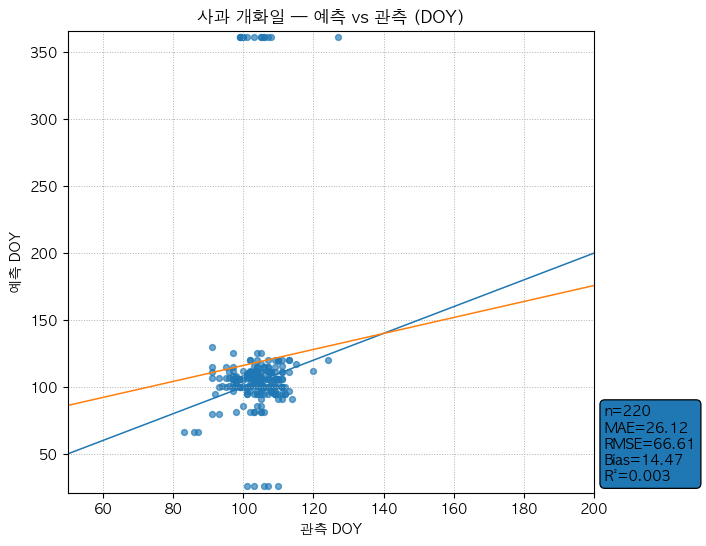

In [45]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams["font.family"] = "AppleGothic"
mpl.rcParams["axes.unicode_minus"] = False

CSV = Path("/Users/doyoung-gil/연구실/데이터/사과/compare_flowering_best_vs_rda.csv")

def read_any(p):
    for enc in ("utf-8-sig","utf-8","cp949","euc-kr"):
        try: return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError: pass
    return pd.read_csv(p, low_memory=False)

df = read_any(CSV).dropna(subset=["obs_doy","flowering_doy"]).copy()
x = pd.to_numeric(df["obs_doy"], errors="coerce").to_numpy(float)
y = pd.to_numeric(df["flowering_doy"], errors="coerce").to_numpy(float)
mask = ~np.isnan(x) & ~np.isnan(y)
x, y = x[mask], y[mask]

# ===== 관측 DOY 범위 50~200만 사용 =====
XR = (50, 200)
in_rng = (x >= XR[0]) & (x <= XR[1])
x, y = x[in_rng], y[in_rng]

# ===== 지표 =====
err  = y - x
mae  = float(np.mean(np.abs(err)))
rmse = float(np.sqrt(np.mean(err**2)))
bias = float(np.mean(err))
b, a = np.polyfit(x, y, 1)  # y = a + b x
n    = len(x)

# ===== 그림 =====
fig, ax = plt.subplots(figsize=(7.8, 6))   # 폭을 조금 넓혀 우측 여백 확보
ax.scatter(x, y, s=18, alpha=0.65)

# 축 범위 고정
ax.set_xlim(*XR)
# y축은 데이터 기반으로 살짝 여유
ymin = max(0, np.nanmin(y) - 5)
ymax = np.nanmax(y) + 5
ax.set_ylim(ymin, ymax)

# 1:1선 + 회귀선 (x축 범위에 맞춰 그림)
xm, xM = XR
ax.plot([xm, xM], [xm, xM], linewidth=1.1, label="1:1")
ax.plot([xm, xM], [a + b*xm, a + b*xM], linewidth=1.1, label="회귀선")

ax.grid(True, linestyle=":", linewidth=0.7)
ax.set_xlabel("관측 DOY")
ax.set_ylabel("예측 DOY")
ax.set_title("사과 개화일 — 예측 vs 관측 (DOY)")

# ===== 요약지표 박스를 그래프 밖(오른쪽)으로 =====
stats = f"n={n}\nMAE={mae:.2f}\nRMSE={rmse:.2f}\nBias={bias:.2f}\nR²={np.corrcoef(x,y)[0,1]**2:.3f}"
# 우측 여백을 더 주고, 축 좌표계 밖으로 x=1.02 위치
plt.subplots_adjust(right=0.80)  # 여백(0.80~0.85 사이로 조절)
ax.text(1.02, 0.02, stats, transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.35", lw=0.9))

plt.show()
# 저장하려면:
# out = CSV.with_name("scatter_50_200_outbox.png"); fig.savefig(out, dpi=240)


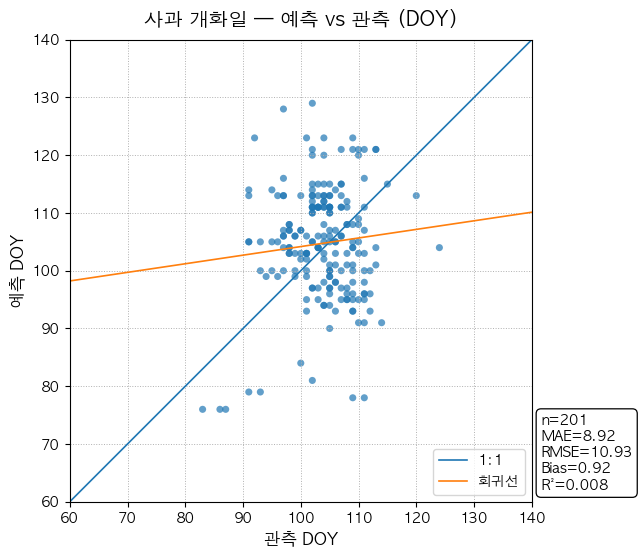

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ===== 폰트/기본 설정 =====
mpl.rcParams["font.family"] = "AppleGothic"   
mpl.rcParams["axes.unicode_minus"] = False    

# ===== 경로 =====
CSV = Path("/Users/doyoung-gil/연구실/데이터/사과/사과_joined_samples/1day_Fuzzy/compare_flowering_best_vs_rda.csv")

# ===== 데이터 로드 =====
def read_any(p: Path) -> pd.DataFrame:
    for enc in ("utf-8-sig", "utf-8", "cp949", "euc-kr"):
        try:
            return pd.read_csv(p, encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            pass
    return pd.read_csv(p, low_memory=False)

df = read_any(CSV)

# 필요 컬럼 확인
need = {"obs_doy", "flowering_doy"}
missing = need - set(df.columns)
if missing:
    raise KeyError(f"필요 컬럼 누락: {missing}")

# 숫자화 & 결측 제거
d = df.dropna(subset=["obs_doy", "flowering_doy"]).copy()
x_all = pd.to_numeric(d["obs_doy"], errors="coerce").to_numpy(float)
y_all = pd.to_numeric(d["flowering_doy"], errors="coerce").to_numpy(float)
mask = ~np.isnan(x_all) & ~np.isnan(y_all)
x_all, y_all = x_all[mask], y_all[mask]

# ===== 관측 DOY 범위 필터 (보기/지표 모두 적용) =====
rng = (60, 140)  
in_rng = (x_all >= rng[0]) & (x_all <= rng[1]) & (y_all >= rng[0]) & (y_all <= rng[1])
x = x_all[in_rng]
y = y_all[in_rng]

# ===== 지표 계산 (필터링 후 데이터 기준) =====
err  = y - x
mae  = float(np.mean(np.abs(err)))
rmse = float(np.sqrt(np.mean(err**2)))
bias = float(np.mean(err))
# 단순 선형회귀 y = a + b x
b, a = np.polyfit(x, y, 1)
yhat = a + b * x
ss_res = float(np.sum((y - yhat) ** 2))
ss_tot = float(np.sum((y - np.mean(y)) ** 2))
r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
n = int(len(x))

# ===== 그림 =====
fig, ax = plt.subplots(figsize=(7.8, 6))

# 점
ax.scatter(x, y, s=26, alpha=0.7, edgecolors="none")

# 1:1선 + 회귀선 (라벨 포함 → 범례 표시 가능)
xm, xM = rng
ax.plot([xm, xM], [xm, xM], linewidth=1.2, label="1:1")
ax.plot([xm, xM], [a + b * xm, a + b * xM], linewidth=1.2, label="회귀선")

# 축/레이블/격자
ax.set_xlim(xm, xM)
ax.set_ylim(xm, xM)  
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle=":", linewidth=0.7)
ax.set_xlabel("관측 DOY", fontsize=12)
ax.set_ylabel("예측 DOY", fontsize=12)
ax.set_title("사과 개화일 — 예측 vs 관측 (DOY)", fontsize=14, pad=10)

# 범례(원하면 위치 조정)
ax.legend(loc="lower right", frameon=True)

# ===== 요약지표 박스를 그래프 밖(오른쪽)에 배치 =====
stats = f"n={n}\nMAE={mae:.2f}\nRMSE={rmse:.2f}\nBias={bias:.2f}\nR²={r2:.3f}"
fig.subplots_adjust(right=0.80)  # 우측 여백 확보
ax.text(1.02, 0.02, stats, transform=ax.transAxes,
        ha="left", va="bottom",
        bbox=dict(boxstyle="round,pad=0.35", lw=0.9, fc="white"))

plt.show()

# 저장하려면 주석


## 사과 만개기 비교